# SUPR-Foot — what the parameters actually do

A foot in this model is one function:

```text
foot = SUPR(pose, betas)
```

- **`betas`** — 100 numbers. *What kind of foot.* Longer, wider, higher arch. Nothing to do with movement.
- **`pose`** — 39 numbers. *How the foot is bent.* Three numbers for each of 13 joints.

You never touch a raw index here. You write `foot(ankle_pitch=30)` and get a foot with the
ankle bent 30 degrees.

**Section 5 is the interactive one** — sliders for every joint, with the code to reproduce
whatever you land on. Two facts worth knowing before you start, both measured rather than assumed:

- The **ankle** and the **midfoot** are the only joints that matter for a heel. The ten toe joints move about twenty points each.
- A heel pose needs **both** of them. The ankle alone tips the whole foot like a wedge.

## 1 — Setup

In [1]:
import os, sys
os.environ["CUDA_VISIBLE_DEVICES"] = "5"          # pick any free GPU

REPO = "/storage/Abhinay/Shell_Gaussian/baselines/SUPR"
if REPO not in sys.path:
    sys.path.insert(0, REPO)

import numpy as np, torch
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from matplotlib.collections import PolyCollection
from supr.pytorch.supr import SUPR

NUM_BETAS      = 100      # the file holds 300; 100 is plenty
FOOT_LENGTH_MM = 250.0    # what we call the neutral foot's length, so results come out in mm
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = SUPR(f"{REPO}/data/supr_male_right_foot.npy", num_betas=NUM_BETAS)
FACES = np.asarray(model.f.detach().cpu().numpy() if torch.is_tensor(model.f) else model.f, np.int64)

print(f"device {DEVICE} | {model.num_joints} joints | {model.num_pose} pose numbers | {len(FACES)} triangles")
print("SUPR only publishes male models, so this is the one foot we have.")

device cuda | 13 joints | 39 pose numbers | 515 triangles
SUPR only publishes male models, so this is the one foot we have.


## 2 — The kit

`foot(...)` makes a foot, `measure(...)` turns it into anatomical numbers, `show(...)` draws it.
Read this cell once, then forget it exists.

`show()` fits its frame to whatever you give it, so a pitched foot never gets clipped.

In [2]:
JOINTS = {"root":0, "ankle":1, "midfoot":2,
          "big_toe":3, "big_toe_tip":4, "toe2":5, "toe2_tip":6, "toe3":7, "toe3_tip":8,
          "toe4":9, "toe4_tip":10, "little_toe":11, "little_toe_tip":12}
TOE_BASES = ("big_toe", "toe2", "toe3", "toe4", "little_toe")

AXES = {"pitch":0, "yaw":1, "roll":2}
AXIS_MEANING = {"pitch":"point the toes down (+) or up (-)",
                "yaw":  "swing the toes inward (+) or outward (-)",
                "roll": "tilt the sole inward (+) or outward (-)"}

RECIPES = {
    "flat":                       {},
    "mid heel":                   {"ankle_pitch": 21, "midfoot_pitch": -18},
    "high heel":                  {"ankle_pitch": 50, "midfoot_pitch": -45},
    "on tiptoe":                  {"ankle_pitch": 45},
    "toes lifted (push-off)":     {"big_toe_pitch": -25, "toe2_pitch": -25, "toe3_pitch": -25,
                                   "toe4_pitch": -25, "little_toe_pitch": -25},
    "foot rolled inward":         {"ankle_roll": 25},
    "toes swung outward":         {"ankle_yaw": -25},
    "foot pulled up (dorsiflex)": {"ankle_pitch": -20},
}

def foot(betas=None, **angles):
    """foot(ankle_pitch=30, midfoot_pitch=-25) -- angles in DEGREES. Returns (vertices, joints)."""
    pose = torch.zeros((1, model.num_pose), dtype=torch.float32, device=DEVICE)
    for key, deg in angles.items():
        joint, _, axis = key.rpartition("_")
        if joint not in JOINTS or axis not in AXES:
            raise KeyError(f"{key!r}: expected <joint>_<axis>. "
                           f"joints={sorted(JOINTS)} axes={sorted(AXES)}")
        pose[0, JOINTS[joint] * 3 + AXES[axis]] = np.deg2rad(deg)
    b = torch.zeros((1, NUM_BETAS), dtype=torch.float32, device=DEVICE)
    for i, v in (betas or {}).items():
        b[0, i] = v
    t = torch.zeros((1, 3), dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        out = model.forward(pose, b, t)
    return out[0].cpu().numpy(), out.J_transformed[0].cpu().numpy()

NEUTRAL, NEUTRAL_J = foot()
UNIT_MM = FOOT_LENGTH_MM / np.ptp(NEUTRAL[:, 2])

def measure(V):
    """Anatomical numbers in mm and degrees. heel_lift = heel above the ball, ball on the floor."""
    z = V[:, 2]; z0, z1 = z.min(), z.max(); span = z1 - z0
    heel = V[z <= z0 + 0.18 * span]
    ball = V[(z >= z0 + 0.55 * span) & (z <= z0 + 0.80 * span)]
    sel  = z >= z0 + 0.60 * span
    bins = np.linspace(z[sel].min(), z[sel].max(), 12); pts = []
    for a, b in zip(bins[:-1], bins[1:]):
        s = sel & (z >= a) & (z < b)
        if s.any():
            pts.append((z[s].mean(), V[s, 1].min()))
    tilt = np.degrees(np.arctan(np.polyfit(*np.array(pts).T, 1)[0])) if len(pts) >= 3 else np.nan
    T  = V[FACES];       n  = np.cross(T[:, 1] - T[:, 0], T[:, 2] - T[:, 0])
    T0 = NEUTRAL[FACES]; n0 = np.cross(T0[:, 1] - T0[:, 0], T0[:, 2] - T0[:, 0])
    return {"bbox_length_mm": np.ptp(V[:, 2]) * UNIT_MM,
            "bbox_width_mm":  np.ptp(V[:, 0]) * UNIT_MM,
            "bbox_height_mm": np.ptp(V[:, 1]) * UNIT_MM,
            "heel_lift_mm":   (heel[:, 1].min() - ball[:, 1].min()) * UNIT_MM,
            "forefoot_tilt_deg": tilt,
            "torn_triangles": int((np.einsum("ij,ij->i", n, n0) < 0).sum()),
            **_stretch(n, n0)}

def _stretch(n, n0):
    """How much triangles changed size. The MAX is dominated by a few tiny creases, so the
    99th percentile and a count of badly stretched triangles are the honest numbers."""
    r = np.linalg.norm(n, axis=1) / np.maximum(np.linalg.norm(n0, axis=1), 1e-12)
    return {"stretch_p99": float(np.percentile(r, 99)),
            "stretch_max": float(r.max()),
            "stretched_triangles": int((r > 1.5).sum()),
            "triangle_count": int(len(r))}

def report(V, label=""):
    m = measure(V)
    print(f"{label:24s} bbox {m['bbox_length_mm']:6.1f} x {m['bbox_width_mm']:5.1f} x "
          f"{m['bbox_height_mm']:5.1f} mm | heel lift {m['heel_lift_mm']:6.1f} mm | "
          f"forefoot {m['forefoot_tilt_deg']:+5.1f} deg | stretch {m['stretch_p99']:.2f}x "
          f"({m['stretched_triangles']}/{m['triangle_count']} tris over 1.5x)"
          + ("  TORN" if m["torn_triangles"] else ""))
    return m

VIEWS = {"side": (2, 1), "top": (2, 0), "front": (0, 1)}

def _floor_y(V):
    z = V[:, 2]; z0, s = z.min(), np.ptp(z)
    return V[(z >= z0 + 0.55 * s) & (z <= z0 + 0.80 * s)][:, 1].min()

def show(*feet, view="side", labels=None, floor=True, ghost=False, figsize=None, pad=0.03):
    """show(NEUTRAL, posed, labels=['flat','heel'], ghost=True)

    The frame is fitted to everything drawn, so nothing is ever clipped, and all
    panels share one scale so the poses are directly comparable."""
    labels = labels or [f"foot {i+1}" for i in range(len(feet))]
    a, b = VIEWS[view]
    other = [i for i in (0, 1, 2) if i not in (a, b)][0]
    shown = list(feet) + ([NEUTRAL] if ghost else [])
    lo_a = min(V[:, a].min() for V in shown); hi_a = max(V[:, a].max() for V in shown)
    lo_b = min(V[:, b].min() for V in shown); hi_b = max(V[:, b].max() for V in shown)
    if floor and view == "side":
        fl = [_floor_y(V) for V in feet]
        lo_b, hi_b = min(lo_b, min(fl)), max(hi_b, max(fl))
    p = pad * max(hi_a - lo_a, hi_b - lo_b) + 1e-9
    ca, cb = (lo_a + hi_a) / 2, (lo_b + hi_b) / 2
    half_a, half_b = (hi_a - lo_a) / 2 + p, (hi_b - lo_b) / 2 + p
    h = figsize[1] if figsize else 3.2 * max(1.0, half_b / half_a)
    fig, axes = plt.subplots(1, len(feet), figsize=figsize or (3.4 * len(feet), h), squeeze=False)
    for ax, V, lab in zip(axes[0], feet, labels):
        if ghost:
            T = NEUTRAL[FACES][:, :, [a, b]]
            o = np.argsort(NEUTRAL[FACES][:, :, other].mean(axis=1))
            ax.add_collection(PolyCollection([T[i] for i in o], facecolors="#00000010",
                                             edgecolors="none", zorder=1))
        T = V[FACES][:, :, [a, b]]
        o = np.argsort(V[FACES][:, :, other].mean(axis=1))
        ax.add_collection(PolyCollection([T[i] for i in o], facecolors="#5B7FA6",
                                         edgecolors="#00000022", linewidths=.25, zorder=2))
        if floor and view == "side":
            ax.axhline(_floor_y(V), color="#C0442A", lw=1.5, ls="--", zorder=3)
        ax.set_title(lab, fontsize=10.5)
        ax.set_xlim(ca - half_a, ca + half_a)
        ax.set_ylim(cb - half_b, cb + half_b)
        ax.set_aspect("equal"); ax.axis("off")
    fig.tight_layout()
    return fig



# ---------------------------------------------------------------- 3D view
def _xyz(V):
    """SUPR raw (x=width, y=up, z=length) -> plot (x=length, y=width, z=height)."""
    return V[:, 2], V[:, 0], V[:, 1]

def _floor_patch(V, pad=1.25):
    z = V[:, 2]; z0, s = z.min(), np.ptp(z)
    y = V[(z >= z0 + 0.55 * s) & (z <= z0 + 0.80 * s)][:, 1].min()
    xs = [V[:, 2].min() - .02, V[:, 2].max() + .02]
    ws = [V[:, 0].min() - .02, V[:, 0].max() + .02]
    cx, cw = np.mean(xs), np.mean(ws)
    xs = [cx + (v - cx) * pad for v in xs]; ws = [cw + (v - cw) * pad for v in ws]
    return (np.array([xs[0], xs[1], xs[1], xs[0]]), np.array([ws[0], ws[0], ws[1], ws[1]]),
            np.array([y] * 4))

def make_view(V, height=540):
    """A rotatable 3D foot. Drag to spin, scroll to zoom, right-drag to pan."""
    x, y, z = _xyz(V); fx, fy, fz = _floor_patch(V)
    fig = go.FigureWidget(data=[
        go.Mesh3d(x=x, y=y, z=z, i=FACES[:, 0], j=FACES[:, 1], k=FACES[:, 2],
                  color="#5B7FA6", flatshading=False, hoverinfo="skip",
                  lighting=dict(ambient=.45, diffuse=.85, specular=.15, roughness=.85),
                  lightposition=dict(x=200, y=-200, z=300)),
        go.Mesh3d(x=fx, y=fy, z=fz, i=[0, 0], j=[1, 2], k=[2, 3],
                  color="#C0442A", opacity=.16, hoverinfo="skip"),
    ])
    fig.update_layout(height=height, margin=dict(l=0, r=0, t=0, b=0), showlegend=False,
        scene=dict(aspectmode="data",
                   xaxis=dict(title="length", showbackground=False, showticklabels=False),
                   yaxis=dict(title="width", showbackground=False, showticklabels=False),
                   zaxis=dict(title="height", showbackground=False, showticklabels=False),
                   camera=dict(eye=dict(x=1.5, y=-1.9, z=0.9))))
    return fig

def update_view(fig, V):
    """Swap in a new foot. The camera angle you set with the mouse is kept."""
    x, y, z = _xyz(V); fx, fy, fz = _floor_patch(V)
    with fig.batch_update():
        fig.data[0].x, fig.data[0].y, fig.data[0].z = x, y, z
        fig.data[1].x, fig.data[1].y, fig.data[1].z = fx, fy, fz

# ------------------------------------------------- what each beta actually does
def _dims_mm(V):
    z = V[:, 2]; z0, s = z.min(), np.ptp(z)
    ball = (z >= z0 + 0.60 * s) & (z <= z0 + 0.80 * s)
    return np.array([np.ptp(V[:, 2]), np.ptp(V[:, 0]), np.ptp(V[:, 1]), np.ptp(V[ball, 0])]) * UNIT_MM

_BASE_DIMS = _dims_mm(NEUTRAL)

def beta_label(i, amount=2.0):
    dl, dw, dh, db = _dims_mm(foot(betas={i: amount})[0]) - _BASE_DIMS
    if abs(dl) > 3 and dw > 0 and dh > 0:                    what = "overall size"
    elif abs(dl) >= max(abs(dw), abs(dh), abs(db)):          what = "longer / shorter"
    elif max(abs(dw), abs(db)) >= abs(dh):                   what = "wider / narrower"
    else:                                                     what = "taller / flatter"
    return f"beta {i} \u2014 {what}"

BETA_LABELS = [beta_label(i) for i in range(6)]

print("kit ready. 1 model unit =", round(UNIT_MM, 1), "mm")
report(NEUTRAL, "neutral foot")

kit ready. 1 model unit = 919.2 mm
neutral foot             bbox  250.0 x  94.7 x  96.6 mm | heel lift    5.5 mm | forefoot  +0.4 deg | stretch 1.00x (0/515 tris over 1.5x)


{'bbox_length_mm': 250.0,
 'bbox_width_mm': 94.66914715624695,
 'bbox_height_mm': 96.63335203808975,
 'heel_lift_mm': 5.510287561249311,
 'forefoot_tilt_deg': 0.35088864706047224,
 'torn_triangles': 0,
 'stretch_p99': 1.0,
 'stretch_max': 1.0,
 'stretched_triangles': 0,
 'triangle_count': 515}

## 3 — The map: what the 39 pose numbers are

Three numbers per joint. The `verts moved` column is the honest measure of how much each
joint matters: the ankle moves 102 of the foot's 266 points, every toe joint under 20.

           name  joint  pose numbers  verts moved   what it is
           root      0           0-2            0   whole foot in space -- leave at 0
          ankle      1           3-5          102   THE heel joint
        midfoot      2           6-8           59   arch -- flattens the forefoot
        big_toe      3          9-11            9   big toe knuckle
    big_toe_tip      4         12-14           15   big toe tip
           toe2      5         15-17            2   2nd toe knuckle
       toe2_tip      6         18-20           18   2nd toe tip
           toe3      7         21-23            4   3rd toe knuckle
       toe3_tip      8         24-26           18   3rd toe tip
           toe4      9         27-29            5   4th toe knuckle
       toe4_tip     10         30-32           14   4th toe tip
     little_toe     11         33-35            3   little toe knuckle
 little_toe_tip     12         36-38           17   little toe tip


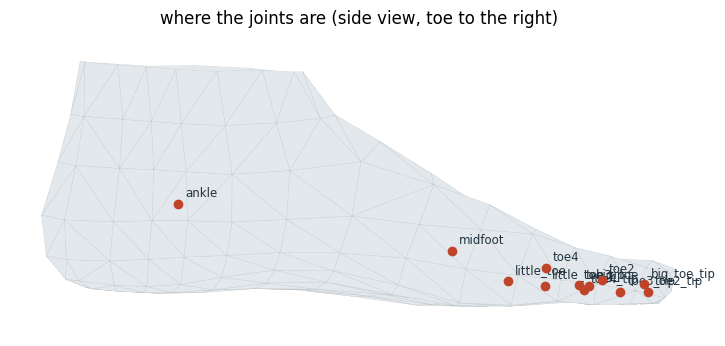

In [3]:
DESC = {"root":"whole foot in space -- leave at 0", "ankle":"THE heel joint",
        "midfoot":"arch -- flattens the forefoot", "big_toe":"big toe knuckle",
        "big_toe_tip":"big toe tip", "toe2":"2nd toe knuckle", "toe2_tip":"2nd toe tip",
        "toe3":"3rd toe knuckle", "toe3_tip":"3rd toe tip", "toe4":"4th toe knuckle",
        "toe4_tip":"4th toe tip", "little_toe":"little toe knuckle", "little_toe_tip":"little toe tip"}

W_ = np.load(f"{REPO}/data/supr_male_right_foot.npy", allow_pickle=True).item()["weights"]
print(f"{'name':>15} {'joint':>6} {'pose numbers':>13} {'verts moved':>12}   what it is")
for name, j in JOINTS.items():
    print(f"{name:>15} {j:6d} {f'{j*3}-{j*3+2}':>13} {int((W_[:, j] > 0.5).sum()):12d}   {DESC[name]}")

fig, ax = plt.subplots(figsize=(9, 4.6))
order = np.argsort(NEUTRAL[FACES][:, :, 0].mean(axis=1))
ax.add_collection(PolyCollection([NEUTRAL[FACES][:, :, [2, 1]][i] for i in order],
                                 facecolors="#E2E8EC", edgecolors="#00000018", linewidths=.25))
labelled = [(n, j) for n, j in JOINTS.items() if n != "root"]
for name, j in labelled:
    ax.plot(NEUTRAL_J[j, 2], NEUTRAL_J[j, 1], "o", ms=6, color="#C0442A", zorder=5)
    ax.annotate(name, (NEUTRAL_J[j, 2], NEUTRAL_J[j, 1]), textcoords="offset points",
                xytext=(5, 5), fontsize=8.5, color="#22333F")

xs = np.concatenate([NEUTRAL[:, 2], NEUTRAL_J[[j for _, j in labelled], 2]])
ys = np.concatenate([NEUTRAL[:, 1], NEUTRAL_J[[j for _, j in labelled], 1]])
mx, my = 0.05 * np.ptp(xs), 0.12 * np.ptp(ys)
ax.set_xlim(xs.min() - mx, xs.max() + mx)
ax.set_ylim(ys.min() - my, ys.max() + my)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("where the joints are (side view, toe to the right)")
plt.show()

## 4 — What the three axes of a joint do

Every joint takes `pitch`, `yaw`, `roll`. Rather than trust the names, this cell bends each
one and reports where the toe tip actually went.

In [4]:
def what_does_axis_do(joint, degrees=20):
    tip = int(np.argmax(NEUTRAL[:, 2]))
    print(f"'{joint}' bent {degrees} deg on each axis -- where the toe tip goes:")
    for axis in AXES:
        V, _ = foot(**{f"{joint}_{axis}": degrees})
        d = (V[tip] - NEUTRAL[tip]) * UNIT_MM
        print(f"   {axis:5s}  inward {d[0]:+6.1f} mm   up {d[1]:+6.1f} mm   forward {d[2]:+6.1f} mm"
              f"   |  {AXIS_MEANING[axis]}")

what_does_axis_do("ankle")
print()
what_does_axis_do("midfoot")

'ankle' bent 20 deg on each axis -- where the toe tip goes:
   pitch  inward   +0.6 mm   up  -65.1 mm   forward  -20.8 mm   |  point the toes down (+) or up (-)
   yaw    inward  +65.3 mm   up   -0.3 mm   forward  -23.2 mm   |  swing the toes inward (+) or outward (-)
   roll   inward   +7.1 mm   up  +13.0 mm   forward   -0.1 mm   |  tilt the sole inward (+) or outward (-)

'midfoot' bent 20 deg on each axis -- where the toe tip goes:
   pitch  inward   +0.2 mm   up  -28.2 mm   forward   -7.0 mm   |  point the toes down (+) or up (-)
   yaw    inward  +26.6 mm   up   -0.1 mm   forward  -14.1 mm   |  swing the toes inward (+) or outward (-)
   roll   inward   +0.7 mm   up   +9.9 mm   forward   -0.5 mm   |  tilt the sole inward (+) or outward (-)


## 5 — Play with it

**Drag the foot to spin it.** Scroll to zoom, right-drag to pan. The angle you set with the
mouse is kept when you move a slider, so you can line up a view once and then explore.

Things worth trying:

- Move **ankle pitch** alone and watch `forefoot` in the readout. It goes badly negative — the ball of the foot is sitting on a slope, not on the floor.
- Now set **midfoot pitch** to the same number negated. `forefoot` comes back to about `0`. That is a heel pose, and the two numbers are always equal and opposite.
- Pick a **preset** to jump to a known pose, then nudge it.
- Watch `stretch` and the `tris over 1.5x` count. A few stretched triangles are normal; a lot of them means the pose is past what the model was trained on.

The **beta** sliders are the six that actually do something — see section 7 for why the
other ninety-four barely move the foot at all.

The line above the readout is the code that reproduces whatever you are looking at.

In [11]:
import ipywidgets as W
from IPython.display import display

def explorer():
    style = {"description_width": "118px"}
    lay   = W.Layout(width="315px")
    mk = lambda d, lo, hi, st=1.0: W.FloatSlider(value=0, min=lo, max=hi, step=st, description=d,
                                                 continuous_update=False, style=style,
                                                 layout=lay, readout_format=".0f")
    ankle = {a: mk(f"ankle {a}", -60, 60) for a in AXES}
    mid   = {a: mk(f"midfoot {a}", -60, 60) for a in AXES}
    toe_j = W.Dropdown(options=list(TOE_BASES), value="big_toe", description="toe",
                       style=style, layout=lay)
    toe_v = mk("toe pitch", -60, 60)
    all_toes = W.Checkbox(value=False, description="all five toes together")
    betas = [W.FloatSlider(value=0, min=-5, max=5, step=0.1, description=BETA_LABELS[i],
                           continuous_update=False, style={"description_width": "170px"},
                           layout=W.Layout(width="380px")) for i in range(6)]
    preset = W.Dropdown(options=["-"] + list(RECIPES), value="-", description="preset",
                        style=style, layout=lay)
    reset  = W.Button(description="reset", icon="undo")
    out    = W.Output()
    sliders = list(ankle.values()) + list(mid.values()) + [toe_v]
    fig = make_view(NEUTRAL)

    def kwargs():
        kw = {}
        for a, s in ankle.items():
            if s.value: kw[f"ankle_{a}"] = s.value
        for a, s in mid.items():
            if s.value: kw[f"midfoot_{a}"] = s.value
        if toe_v.value:
            for j in (TOE_BASES if all_toes.value else (toe_j.value,)):
                kw[f"{j}_pitch"] = toe_v.value
        return kw

    def beta_dict():
        return {i: s.value for i, s in enumerate(betas) if s.value}

    def redraw(_=None):
        kw, b = kwargs(), beta_dict()
        V, _j = foot(betas=b or None, **kw)
        update_view(fig, V)
        parts = ([f"betas={b}"] if b else []) + [f"{k}={v:g}" for k, v in kw.items()]
        with out:
            out.clear_output(wait=True)
            print("foot(" + ", ".join(parts) + ")")
            report(V, "current")

    def on_preset(_):
        if preset.value == "-":
            return
        for s in sliders: s.value = 0
        all_toes.value = False
        R = RECIPES[preset.value]
        toes = {k: v for k, v in R.items() if "toe" in k}
        for k, v in R.items():
            j, _, a = k.rpartition("_")
            if j == "ankle":     ankle[a].value = v
            elif j == "midfoot": mid[a].value = v
        if len(toes) > 1:
            all_toes.value = True; toe_v.value = list(toes.values())[0]
        elif toes:
            toe_j.value = list(toes)[0].rpartition("_")[0]
            toe_v.value = list(toes.values())[0]
        redraw()

    def on_reset(_):
        preset.unobserve(on_preset, names="value")
        preset.value = "-"
        preset.observe(on_preset, names="value")
        for s in sliders + betas: s.value = 0
        all_toes.value = False
        redraw()

    for w in sliders + betas + [toe_j, all_toes]:
        w.observe(redraw, names="value")
    preset.observe(on_preset, names="value")
    reset.on_click(on_reset)

    controls = W.VBox([
        W.HTML("<b>the two joints that matter</b>"),
        W.HBox([W.VBox(list(ankle.values())), W.VBox(list(mid.values()))]),
        W.HTML("<b>toes</b>"), W.HBox([toe_j, toe_v, all_toes]),
        W.HTML("<b>shape &mdash; the six betas that do something</b>"),
        W.HBox([W.VBox(betas[:3]), W.VBox(betas[3:])]),
        W.HBox([preset, reset]),
    ])
    display(W.VBox([controls, fig, out]))
    redraw()

explorer()

## 6 — Which parameters give which pose

The presets from the explorer, side by side, with what each one costs. This is the cheat
sheet: read off the pose you want, take the parameters.

Note `on tiptoe` versus `high heel` — nearly the same heel lift, completely different
forefoot. Tiptoe is the ankle alone; a heel needs the midfoot too.

The toe rows have a higher stretch than their small movement suggests. That is because the
toe knuckles only have a handful of points assigned to them, so bending one distorts a tiny
patch a lot. It is a property of this cut-down foot model, not something you did wrong.

pose                            heel lift   forefoot  stretch   parameters
flat                                  6mm      +0.4d     1.00   {}
mid heel                             50mm      -2.8d     1.17   {'ankle_pitch': 21, 'midfoot_pitch': -18}
high heel                            86mm      -4.4d     1.52   {'ankle_pitch': 50, 'midfoot_pitch': -45}
on tiptoe                           119mm     -39.1d     1.19   {'ankle_pitch': 45}
toes lifted (push-off)                6mm      +4.8d     1.31   {'big_toe_pitch': -25, 'toe2_pitch': -25, 'toe3_pitch': -25, 'toe4_pitch': -25, 'little_toe_pitch': -25}
foot rolled inward                   18mm      +7.6d     1.03   {'ankle_roll': 25}
toes swung outward                    4mm      +1.3d     1.06   {'ankle_yaw': -25}
foot pulled up (dorsiflex)          -38mm     +19.8d     1.04   {'ankle_pitch': -20}


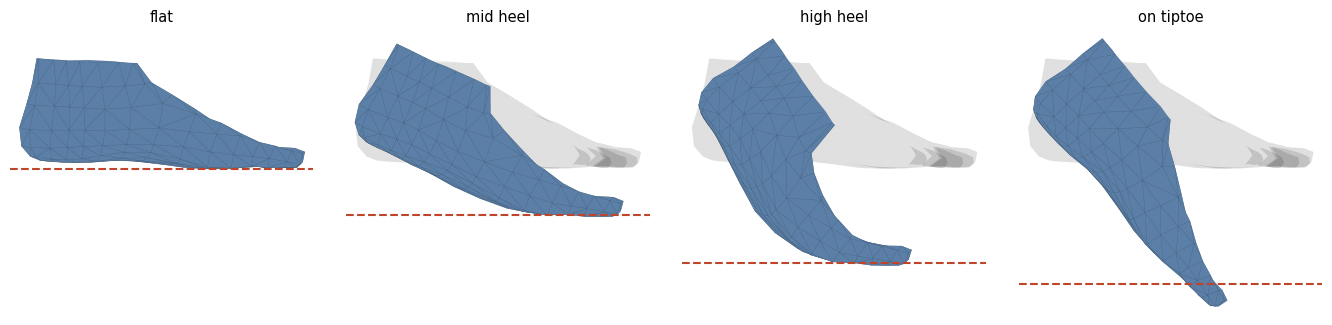

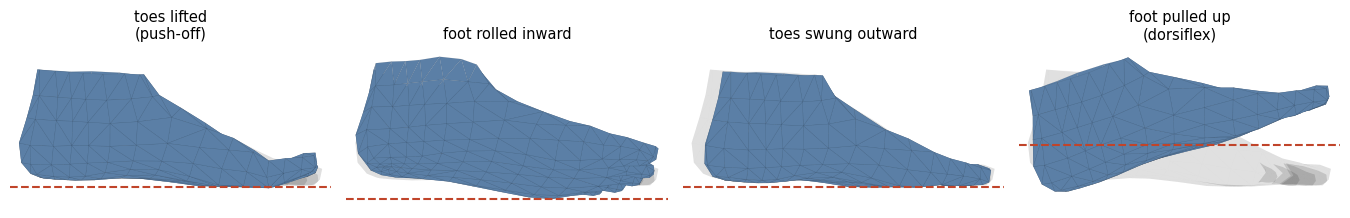

In [6]:
print(f"{'pose':30s} {'heel lift':>10} {'forefoot':>10} {'stretch':>8}   parameters")
feet, labels = [], []
for name, kw in RECIPES.items():
    V, _ = foot(**kw)
    m = measure(V)
    print(f"{name:30s} {m['heel_lift_mm']:8.0f}mm {m['forefoot_tilt_deg']:+9.1f}d "
          f"{m['stretch_p99']:8.2f}   {kw if kw else '{}'}")
    feet.append(V); labels.append(name.replace(" (", "\n("))

show(*feet[:4], labels=labels[:4], ghost=True); plt.show()
show(*feet[4:], labels=labels[4:], ghost=True); plt.show()

## 7 — Why most `betas` seem to do nothing

You will have noticed the beta sliders barely move the foot. That is not a bug, and it is
worth understanding.

The 100 betas are not 100 equal dials. They are **learned shape directions, sorted strongest
first** — the first one captures the biggest way real feet differ from each other, the second
captures the biggest remaining difference, and so on. By the time you reach beta 50 there is
almost nothing left to describe.

The cell below measures this directly from the model file, so you can see the drop-off
rather than take my word for it.

How far one unit of each beta moves the foot:
    beta      moves   what it does
       0    3.87 mm   beta 0 — overall size
       1    1.68 mm   beta 1 — longer / shorter
       2    1.28 mm   beta 2 — wider / narrower
       3    0.97 mm   beta 3 — longer / shorter
       4    0.72 mm   beta 4 — wider / narrower
       5    0.67 mm   beta 5 — longer / shorter
      10    0.41 mm   
      20    0.19 mm   
      50    0.06 mm   
      99    0.02 mm   
     299    0.00 mm   

Share of all the shape variation:
   first   1 betas  18.1%
   first   5 betas  39.8%
   first  10 betas  52.2%
   first  50 betas  81.3%
   first 100 betas  90.3%
   first 300 betas  100.0%

   beta 0 is 9x stronger than beta 9, and 155x stronger than beta 99.
   We load 100 of the 300; the ones we leave out carry 9.7%.

Setting each of the first six to +2 changes the foot by:
    beta   longer    wider   taller   reads as            
       0    +21.8     +4.7     +9.4   overall size        
       1     -3.6   

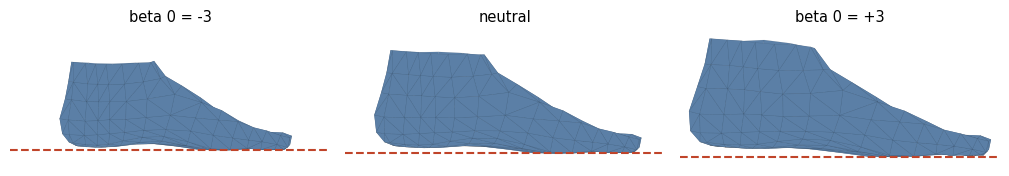

In [7]:
raw = np.load(f"{REPO}/data/supr_male_right_foot.npy", allow_pickle=True).item()
S = np.asarray(raw["shapedirs"])                       # (vertices, xyz, 300)
move = np.sqrt((S ** 2).sum(axis=1).mean(axis=0)) * UNIT_MM   # mm moved per 1.0 of each beta

print("How far one unit of each beta moves the foot:")
print(f"   {'beta':>5} {'moves':>10}   {'what it does' if True else ''}")
for i in list(range(6)) + [10, 20, 50, 99, 299]:
    lab = BETA_LABELS[i] if i < len(BETA_LABELS) else ""
    print(f"   {i:5d} {move[i]:7.2f} mm   {lab}")

tot = move.sum()
print("\nShare of all the shape variation:")
for k in (1, 5, 10, 50, 100, 300):
    print(f"   first {k:3d} betas  {move[:k].sum()/tot:5.1%}")
print(f"\n   beta 0 is {move[0]/move[9]:.0f}x stronger than beta 9, "
      f"and {move[0]/move[99]:.0f}x stronger than beta 99.")
print(f"   We load {NUM_BETAS} of the 300; the ones we leave out carry {move[NUM_BETAS:].sum()/tot:.1%}.")

# what the useful ones actually change, in millimetres
print("\nSetting each of the first six to +2 changes the foot by:")
print(f"   {'beta':>5} {'longer':>8} {'wider':>8} {'taller':>8}   {'reads as':<20}")
base = measure(NEUTRAL)
for i in range(6):
    m = measure(foot(betas={i: 2.0})[0])
    print(f"   {i:5d} {m['bbox_length_mm']-base['bbox_length_mm']:+8.1f} "
          f"{m['bbox_width_mm']-base['bbox_width_mm']:+8.1f} "
          f"{m['bbox_height_mm']-base['bbox_height_mm']:+8.1f}   {BETA_LABELS[i].split(chr(8212))[1].strip():<20}")

show(foot(betas={0: -3.0})[0], NEUTRAL, foot(betas={0: 3.0})[0],
     labels=["beta 0 = -3", "neutral", "beta 0 = +3"])
plt.show()

## 8 — A heel pose from one measurement

This is the part that connects to the shoe work. Measure how far a shoe's footbed rises
from the ball to the heel seat, and this hands you the two angles that put a foot in it
with the forefoot still flat.

target  30 mm  ->  ankle_pitch=12, midfoot_pitch=-16   (gives 30 mm, forefoot +3.5 deg, stretch 1.14x)
target  50 mm  ->  ankle_pitch=21, midfoot_pitch=-18   (gives 50 mm, forefoot -2.8 deg, stretch 1.17x)
target  70 mm  ->  ankle_pitch=38, midfoot_pitch=-38   (gives 70 mm, forefoot +0.3 deg, stretch 1.42x)
target  90 mm  ->  ankle_pitch=52, midfoot_pitch=-46   (gives 89 mm, forefoot -3.6 deg, stretch 1.53x)


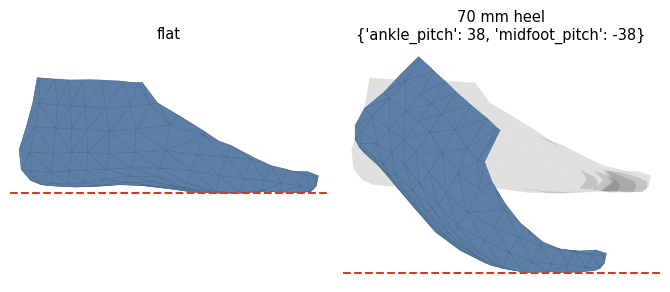

In [8]:
def heel_pose(target_lift_mm, max_tilt=4.0, verbose=True):
    """Angles that lift the heel by target_lift_mm with the forefoot still flat."""
    best = None
    for ank in range(5, 61):
        for mid in range(0, -61, -2):
            m = measure(foot(ankle_pitch=ank, midfoot_pitch=mid)[0])
            if abs(m["forefoot_tilt_deg"]) > max_tilt:
                continue
            err = abs(m["heel_lift_mm"] - target_lift_mm)
            if best is None or err < best[0]:
                best = (err, ank, mid, m)
    if best is None:
        print(f"no flat-footed pose found for {target_lift_mm} mm")
        return None
    _, ank, mid, m = best
    if verbose:
        print(f"target {target_lift_mm:>3.0f} mm  ->  ankle_pitch={ank}, midfoot_pitch={mid}"
              f"   (gives {m['heel_lift_mm']:.0f} mm, forefoot {m['forefoot_tilt_deg']:+.1f} deg,"
              f" stretch {m['stretch_p99']:.2f}x)")
    return {"ankle_pitch": ank, "midfoot_pitch": mid}

for target in (30, 50, 70, 90):
    heel_pose(target)

p = heel_pose(70, verbose=False)
show(NEUTRAL, foot(**p)[0], labels=["flat", f"70 mm heel\n{p}"], ghost=True)
plt.show()

## 9 — Export

Writes into `output/` inside this repo.

In [10]:
from pathlib import Path

def save_mesh(path, V, F=None):
    F = FACES if F is None else F
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w") as fh:
        if path.suffix == ".obj":
            for v in V: fh.write(f"v {v[0]:.8f} {v[1]:.8f} {v[2]:.8f}\n")
            for t in F: fh.write(f"f {t[0]+1} {t[1]+1} {t[2]+1}\n")
        else:
            fh.write(f"ply\nformat ascii 1.0\nelement vertex {len(V)}\n"
                     "property float x\nproperty float y\nproperty float z\n"
                     f"element face {len(F)}\nproperty list uchar int vertex_indices\nend_header\n")
            for v in V: fh.write(f"{v[0]:.8f} {v[1]:.8f} {v[2]:.8f}\n")
            for t in F: fh.write(f"3 {t[0]} {t[1]} {t[2]}\n")
    print("wrote", path)
    return path

out_dir = Path(REPO) / "output" / "supr_explorer"
save_mesh(out_dir / "foot_flat.obj", NEUTRAL)
save_mesh(out_dir / "foot_heel70.obj", foot(**heel_pose(70, verbose=False))[0])

wrote /storage/Abhinay/Shell_Gaussian/baselines/SUPR/output/supr_explorer/foot_flat.obj


KeyboardInterrupt: 

## 10 — Scratch

- `report(foot(ankle_roll=15)[0], "rolled")` — what inversion does to the measurements.
- `show(foot(big_toe_pitch=-30)[0], view="top", ghost=True)` — how little one toe joint moves.
- `foot(betas={0: 1.5}, ankle_pitch=25, midfoot_pitch=-22)` — shape and pose together.
- `heel_pose(100)` — where the model runs out of range.